## Paso 1. Abrir archivos y llevar a cabo el análisis exploratorio de los datos. 

Enlace a mi presentación  

https://gamma.app/docs/Analisis-de-Datos-de-Telecomunicaciones-mkd2y7zn6wnn2ap

In [1]:
# Cargar librerias.
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
# cargar los archivos.
data = pd.read_csv("/datasets/telecom_dataset_us.csv")

In [3]:
data

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25
...,...,...,...,...,...,...,...,...,...
53897,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,True,1,0,38
53898,168606,2019-11-11 00:00:00+03:00,out,True,957922.0,False,2,479,501
53899,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190
53900,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190


In [4]:
clientes = pd.read_csv("/datasets/telecom_clients_us.csv")

In [5]:
clientes

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16
...,...,...,...
727,166554,B,2019-08-08
728,166911,B,2019-08-23
729,167012,B,2019-08-28
730,166867,B,2019-08-22


## Paso 2. Preparar los datos

In [6]:
# Convertir los datos en los tipos necesarios.

In [7]:
data.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [9]:
clientes.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [10]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [11]:
# Encontrar y eliminar errores en los datos, asegurando explicar que errores se encontraron

- Encontrar valores ausentes 

In [12]:
data.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [13]:
data[["user_id","operator_id"]].drop_duplicates()

,user_id,operator_id
0,166377,NaN
1,166377,880022.0
2,166377,880020.0
10,166377,881278.0
14,166377,880028.0
...,...,...
53810,168601,952916.0
53882,168603,959118.0
53889,168603,NaN
53890,168606,957922.0


In [14]:
data["operator_id"].fillna(999,inplace=True)

Para identificar la filas sin operador se va a colocar el numero 999

In [15]:
clientes.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

- valores duplicados

In [16]:
data.duplicated().sum()

4900

In [17]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

0

Se eliminarón los duplicados del dataframe data

In [18]:
clientes.duplicated().sum()

0

- Corregir fechas

In [19]:
data["date"] = pd.to_datetime(data["date"],format='%Y-%m-%d')
data["date"].dtype

datetime64[ns, pytz.FixedOffset(180)]

In [20]:
clientes["date_start"] = pd.to_datetime(clientes["date_start"], format='%Y-%m-%d')
clientes["date_start"].dtype

dtype('<M8[ns]')

En este paso cambiamos las fechas de ambos dataframes a la forma datetime.

## Paso 3. Análisis de datos.

In [21]:
# Identificar operaciones ineficientes

In [22]:
data.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,49002.000000,49002.000000,49002.000000,49002.000000,49002.000000
mean,167294.892759,777219.831966,16.462777,866.282091,1156.558202
std,598.558965,329415.552666,63.604098,3775.503352,4451.473661
min,166377.000000,999.000000,1.000000,0.000000,0.000000
25%,166782.000000,890416.000000,1.000000,0.000000,46.000000
50%,167158.000000,906406.000000,4.000000,37.000000,208.000000
75%,167819.000000,929884.000000,12.000000,570.000000,901.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [23]:
data["wait_time"] = data["total_call_duration"] - data["call_duration"]

<AxesSubplot:xlabel='calls_count', ylabel='Count'>

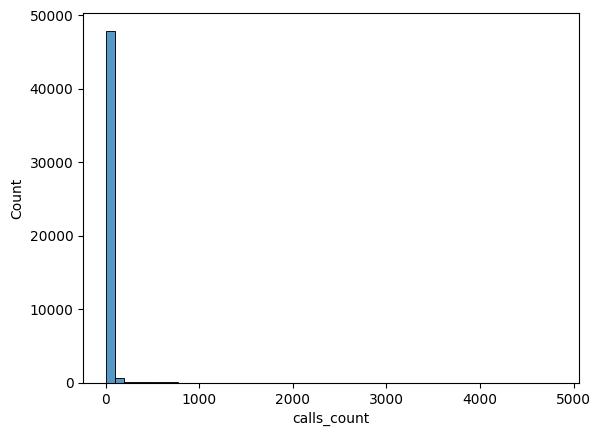

In [24]:
sns.histplot(data=data,x="calls_count",bins=50)

En conclusión los operadores hacen muy pocas llamadas.

<AxesSubplot:xlabel='wait_time', ylabel='Count'>

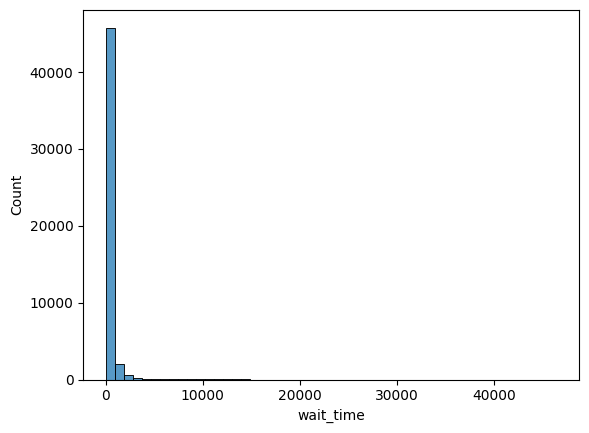

In [25]:
sns.histplot(data=data,x="wait_time",bins=50)

En conclusión los operadores tienen muy poco tiempo de espera.

<AxesSubplot:xlabel='call_duration', ylabel='Count'>

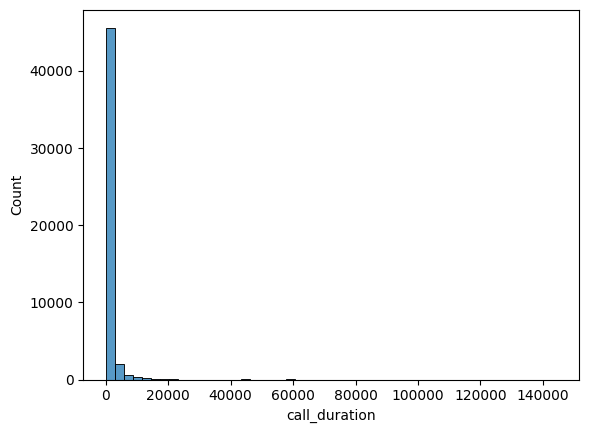

In [26]:
sns.histplot(data=data,x="call_duration",bins=50)

En conclusión los operadores tienen llamadas con duración corta.

In [27]:
operator_data = data.groupby("operator_id").agg({"calls_count":"sum","wait_time":"mean","is_missed_call":["sum","count"]})

In [28]:
operator_data.sort_values(("calls_count","sum"),ascending=False)

calls_count    wait_time is_missed_call      
                    sum         mean            sum count
operator_id                                              
999.0            104564   170.209898           7343  7456
885890.0          60221  5703.565217            101   253
885876.0          59429  4838.459364            115   283
929428.0          23754  5478.123077             32    65
925922.0          20021  5805.027397             30    73
...                 ...          ...            ...   ...
940512.0              1    19.000000              0     1
940514.0              1    11.000000              0     1
960666.0              1     3.000000              0     1
941816.0              1    10.000000              0     1
891254.0              1    26.000000              0     1

[1093 rows x 4 columns]

En conclusión aqui vemos como nos da la columna operator_id de mayor a menor y tan solo entre el primero y el segundo hay una gran diferencia.

- Valores atipicos

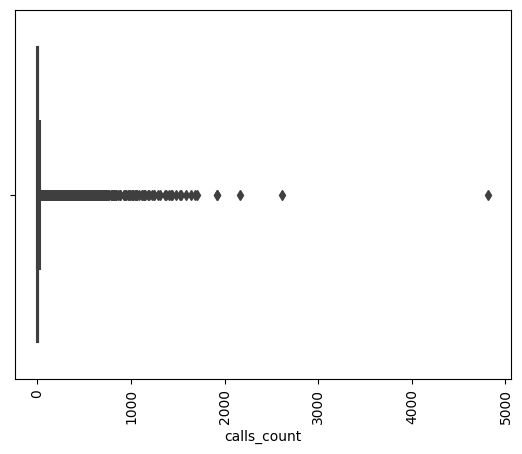

In [29]:
# Traza un diagrama de caja para visualizar la distribución de los calls_count
sns.boxplot(x=data["calls_count"])
plt.xticks(rotation=90)
plt.show()

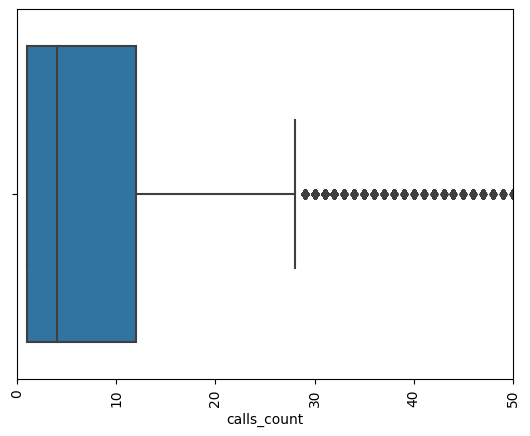

In [30]:
sns.boxplot(x=data["calls_count"])
plt.xticks(rotation=90)
plt.xlim(0,50)
plt.show()

La mediana esta cerca del cero, hay muchos valores atípicos altos y la distribución es muy sesgada.

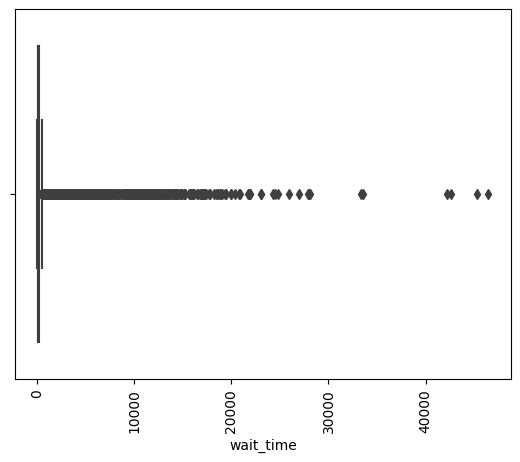

In [31]:
# Traza un diagrama de caja para visualizar la distribución de los wait_time
sns.boxplot(x=data["wait_time"])
plt.xticks(rotation=90)
plt.show()

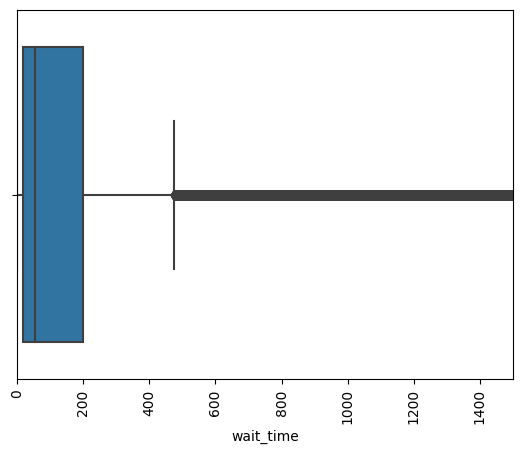

In [32]:
sns.boxplot(x=data["wait_time"])
plt.xticks(rotation=90)
plt.xlim(0,1500)
plt.show()

Los tiempos de espera son bajos, hay operadores con tiempos excesivos y la variabilidad es alta.

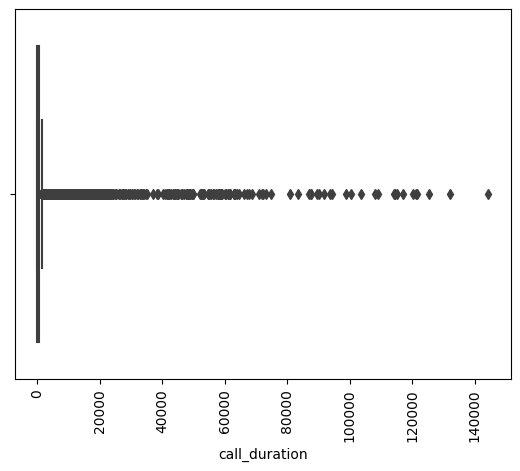

In [33]:
# Traza un diagrama de caja para visualizar la distribución de los call_duration
sns.boxplot(x=data["call_duration"])
plt.xticks(rotation=90)
plt.show()

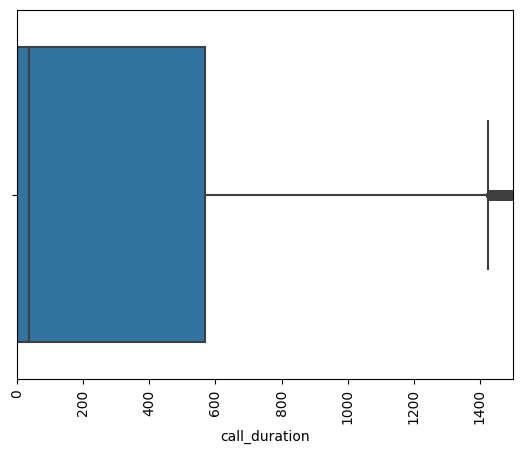

In [34]:
sns.boxplot(x=data["call_duration"])
plt.xticks(rotation=90)
plt.xlim(0,1500)
plt.show()

Las llamadas son cortas y etremadamente largas y la distribución sugiere eficencia.

## Paso 4. Prueba de Hipotesis.

In [35]:
# Primero unir nuestros dataframes
data_1 = data.merge(clientes,
                 on="user_id")
                 
data_1                 

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,wait_time,tariff_plan,date_start
0,166377,2019-08-04 00:00:00+03:00,in,False,999.0,True,2,0,4,4,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,5,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,1,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,8,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,25,B,2019-08-01
...,...,...,...,...,...,...,...,...,...,...,...,...
48997,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,False,1,0,25,25,C,2019-10-31
48998,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,True,1,0,38,38,C,2019-10-31
48999,168606,2019-11-11 00:00:00+03:00,out,True,957922.0,False,2,479,501,22,C,2019-10-31
49000,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190,60,C,2019-10-31


In [36]:
# segundo paso muestra de datos
Plan_A = data_1[data_1["tariff_plan"]=="A"]["wait_time"]
display(Plan_A)
Plan_B = data_1[data_1["tariff_plan"]=="B"]["wait_time"]
Plan_B

2025       24
2026       15
2027        1
2028       15
2029       19
         ... 
48318    1168
48319     410
48320    1616
48321     883
48702       5
Name: wait_time, Length: 13556, dtype: int64

0         4
1         5
2         1
3         8
4        25
         ..
48986    59
48987    10
48988    85
48989    23
48990    30
Name: wait_time, Length: 17237, dtype: int64

En conclusión aqui vemos lo que hay tanto en A y B.

In [37]:
#Imprimir variables
print(Plan_A.var())
Plan_B.var()

3705527.2476806785


109094.283064606

En conclusión vemos que las varianzas no son iguales y es por eso que nuestro equal_var es igual a false.

In [38]:
# formular la hipotesis nula y alternativa
alpha=0.05
result = st.ttest_ind(Plan_A,Plan_B,equal_var=False)

print("p-value",result.pvalue)

if result.pvalue < alpha:
    print("Rechazamos la hipotesis nula")
else:
    print("No podemos rechazar la hipotesis nula")

p-value 1.7574006927319975e-146
Rechazamos la hipotesis nula


En conclusión vemos que rechazamos la hipotesis nula y el valor de p-value es muy pequeño.

## Paso 5. Conclusiones.